# Vision-Language Models with CLIP

# 🎯 Learning Objectives

By the end of this notebook, you will:
- Practice encoding images and text into shared embedding spaces using CLIP (Contrastive Language-Image Pretraining)
- Build zero-shot image classifier
- Create zero-shot cross-modal retrieval setups (image-to-text, text-to-image)

## 📚 What are Vision-Language Models?

Vision-language models are AI systems that can understand both images and text simultaneously.
They learn to map visual and textual information into a shared representation space where
similar concepts (whether expressed in images or words) are close together.

**CLIP** is one of the most influential vision-language models, developed by OpenAI.
It was trained on 400 million (image, text) pairs from the internet using contrastive learning.

![CLIP](https://towardsdatascience.com/wp-content/uploads/2021/04/1tg7akErlMSyCLQxrMtQIYw.png)

### Key Applications:
- Zero-shot image classification
- Cross-modal retrieval

In [1]:
# Install required packages
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers pillow requests matplotlib seaborn ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

# Import libraries
import os
import json
import time
import requests
import random
import warnings
import torch
import clip
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from io import BytesIO
from tqdm import tqdm
from typing import List, Tuple, Dict
from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset

warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-3xr3h37c
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-3xr3h37c
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8a79c6b94dfded3d62de9ed0eeb5138241b349ca1d254510d32f43ca7ef3aff0
  Stored in directory: /tmp/pip-ephem-wheel-cache-d3latqpr/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


##### Loading CLIP model

In [2]:
# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load CLIP model (ViT-B/32 is a good balance of speed and performance)
# Available models: "RN50", "RN101", "RN50x4", "RN50x16", "RN50x64", "ViT-B/32", "ViT-B/16", "ViT-L/14"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print("CLIP model loaded successfully")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


100%|███████████████████████████████████████| 338M/338M [00:11<00:00, 30.0MiB/s]


CLIP model loaded successfully
Model parameters: 151,277,313


##### Define util methods

In [3]:
def load_image_from_url(url: str) -> Image.Image:
  """Load image from URL"""
  try:
      response = requests.get(url, timeout=2)
      return Image.open(BytesIO(response.content)).convert('RGB')
  except Exception as e:
      print(f"Error loading image: {e}")
      return None

def encode_image(image: Image.Image, normalize=True) -> torch.Tensor:
  """Encode image using CLIP"""
  if image is None:
    return None
  image_input = preprocess(image).unsqueeze(0).to(device)
  with torch.no_grad():
    image_features = model.encode_image(image_input)
  if normalize:
    image_features = F.normalize(image_features, dim=-1)
  return image_features

def encode_text(texts: List[str], normalize=True) -> torch.Tensor:
  """Encode list of texts using CLIP"""
  text_tokens = clip.tokenize(texts).to(device)
  with torch.no_grad():
    text_features = model.encode_text(text_tokens)
  if normalize:
    text_features = F.normalize(text_features, dim=-1)
  return text_features

def compute_similarity(image_features: torch.Tensor, text_features: torch.Tensor) -> torch.Tensor:
  """Compute cosine similarity between image and text features"""
  logit_scale = model.logit_scale.exp() # inverse of temperature
  logits = logit_scale * image_features @ text_features.T
  return logits.softmax(dim=-1)

def plot_image_with_scores(image: Image.Image, texts: List[str], scores: np.ndarray, title: str = ""):
  """Plot image with similarity scores"""
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

  ax1.imshow(image)
  ax1.axis('off')
  ax1.set_title(title if title else "Input Image")

  colors = plt.cm.viridis(scores / scores.max())
  bars = ax2.barh(texts, scores, color=colors)
  ax2.set_xlabel('Similarity Score')
  ax2.set_title('Text Similarity Scores')

  for i, (bar, score) in enumerate(zip(bars, scores)):
      ax2.text(score + 0.01, bar.get_y() + bar.get_height()/2,
              f'{score:.3f}', va='center', fontsize=10)

  plt.tight_layout()
  plt.show()

logit_scale.exp() is the inverse temperature.
* A higher logit_scale → sharper similarity scores (softmax picks a few strong matches).
* A lower logit_scale → smoother distribution (softmax spreads attention across candidates).

### Zero-Shot Image Classification
Zero-shot classification means classifying images into categories that the model wasn't explicitly trained on. CLIP can do this by comparing image features with text descriptions of categories.

In this exercise, you'll build a classifier for different animal species.

In [4]:
animal_images = {
    "dog": "https://yumove.co.uk/cdn/shop/articles/Dog_ageing_puppy_da5d1eeb-9265-4925-adc2-24396ff6e7aa.jpg?v=1739461142",
    "siamese_cat": "https://i.redd.it/955h4hhrz2781.jpg",
    "tiger": "https://i.redd.it/4nhqhbj85ik41.jpg",
    "elephant": "https://preview.redd.it/k6nn3qao7jx61.jpg?auto=webp&s=1f86f60fd795682e66a1e8da65944d3e5ec9033c"
}

animal_categories = [
    "a dog",
    "a siamese cat",
    "a colorful parrot",
    "a tiger",
    "an elephant",
    "a horse",
    "a lion",
    "a penguin"
]

prompt_template = "a photo of {}"
prompts = [prompt_template.format(category) for category in animal_categories]

print("Prompt examples:")
for prompt in prompts:
    print(prompt)

Prompt examples:
a photo of a dog
a photo of a siamese cat
a photo of a colorful parrot
a photo of a tiger
a photo of an elephant
a photo of a horse
a photo of a lion
a photo of a penguin


In [5]:
def classify_image(image: Image.Image, prompts: List[str], show_plot: bool = True) -> Tuple[str, float, np.ndarray]:
    """Classify image into one of the given prompts"""
    image_features = encode_image(image)
    text_features = encode_text(prompts)
    similarities = compute_similarity(image_features, text_features)
    scores = similarities.detach().cpu().numpy().flatten()

    best_idx = np.argmax(scores)
    best_category = prompts[best_idx]
    best_score = scores[best_idx]

    if show_plot:
        plot_image_with_scores(image, prompts, scores)

    return best_category, best_score, scores

#### Test on all the samples


🔍 Classifying: dog


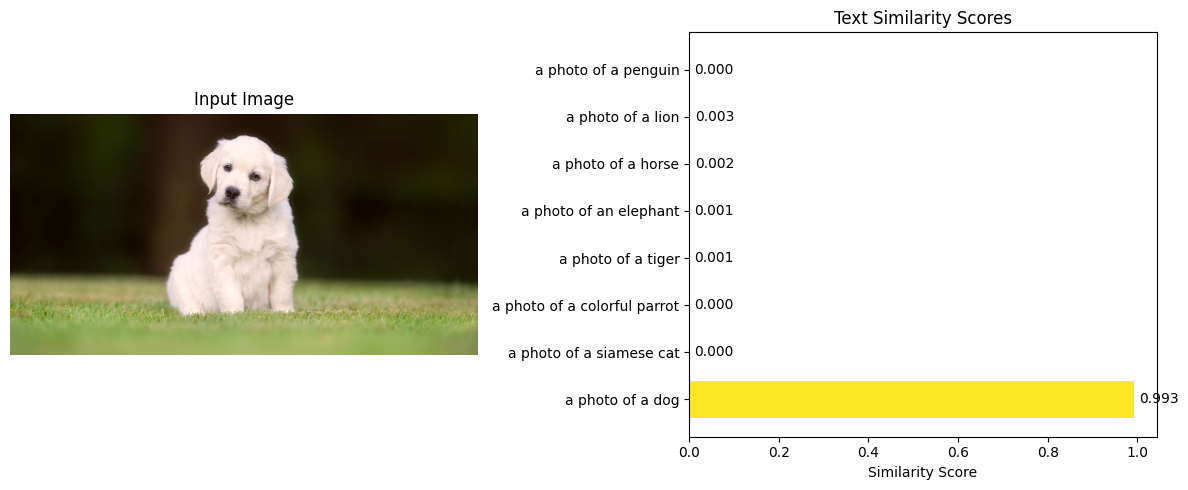

Prediction: a photo of a dog (confidence: 0.993)

🔍 Classifying: siamese_cat


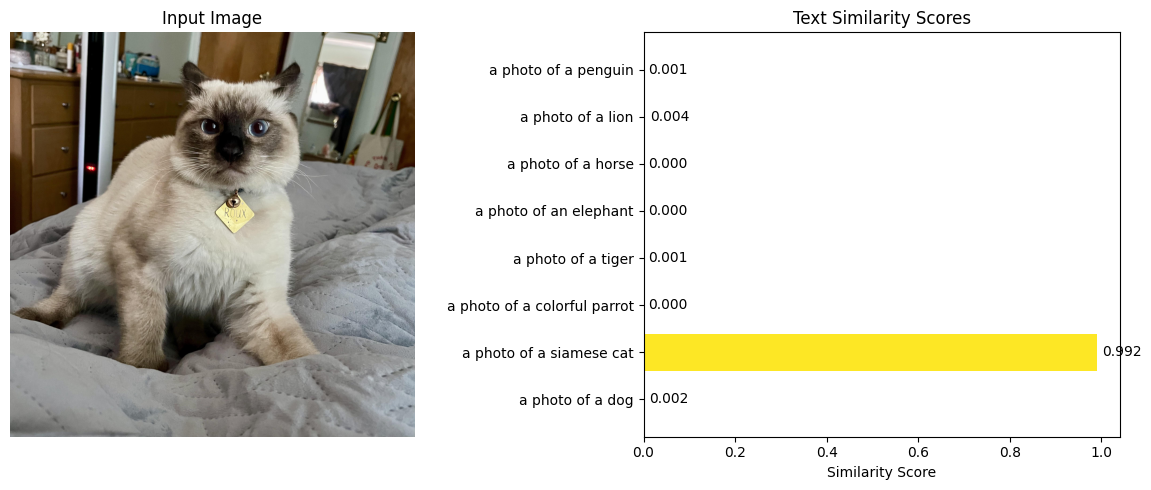

Prediction: a photo of a siamese cat (confidence: 0.992)

🔍 Classifying: tiger


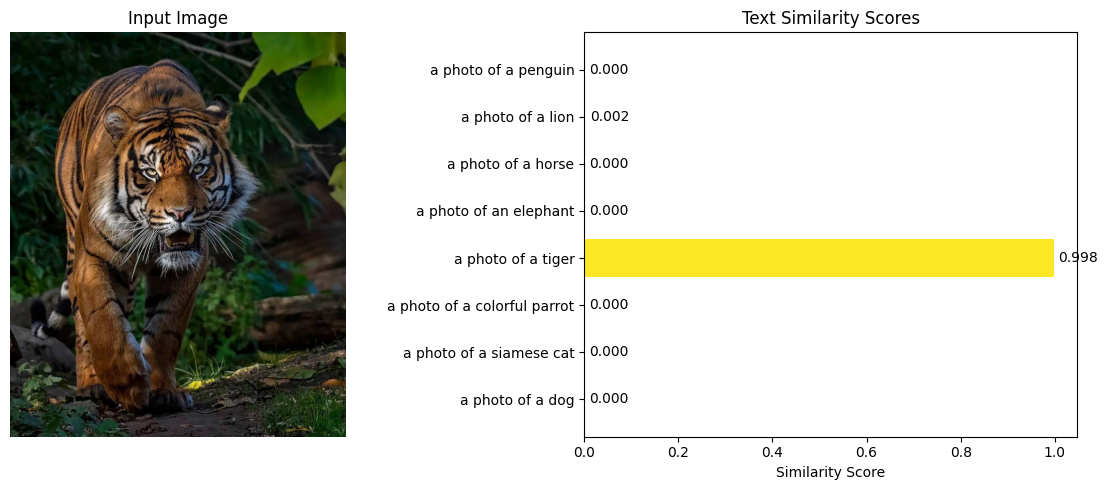

Prediction: a photo of a tiger (confidence: 0.998)

🔍 Classifying: elephant


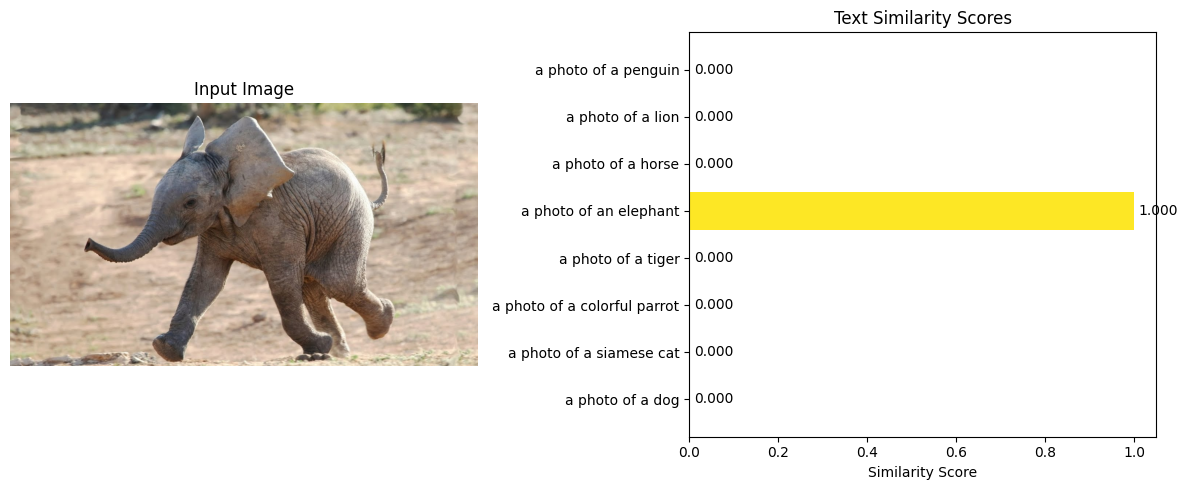

Prediction: a photo of an elephant (confidence: 1.000)

📊 CLASSIFICATION SUMMARY:
----------------------------------------
dog             → a photo of a dog     (0.993)
siamese_cat     → a photo of a siamese cat (0.992)
tiger           → a photo of a tiger   (0.998)
elephant        → a photo of an elephant (1.000)


In [6]:
results = {}
for animal_name, image_url in animal_images.items():
    print(f"\n🔍 Classifying: {animal_name}")
    image = load_image_from_url(image_url)

    if image:
        predicted_category, confidence, all_scores = classify_image(image, prompts)
        results[animal_name] = {
            'predicted': predicted_category,
            'confidence': confidence,
            'scores': all_scores
        }
        print(f"Prediction: {predicted_category} (confidence: {confidence:.3f})")

# Summary of results
print("\n📊 CLASSIFICATION SUMMARY:")
print("-" * 40)
for animal, result in results.items():
    print(f"{animal:15} → {result['predicted']:20} ({result['confidence']:.3f})")

#### Prompt Design Influences Classification
Test different prompt templates for the same categories

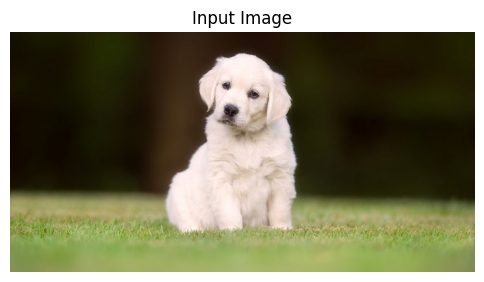


🔍 Classifying the dog image with different prompt templates:
  Template: '{}' -> Prediction: a dog (confidence: 0.977)
  Template: 'a photo of {}' -> Prediction: a photo of a dog (confidence: 0.993)
  Template: 'this is {}' -> Prediction: this is a dog (confidence: 0.949)
  Template: 'definitely not a {}' -> Prediction: definitely not a a dog (confidence: 0.802)


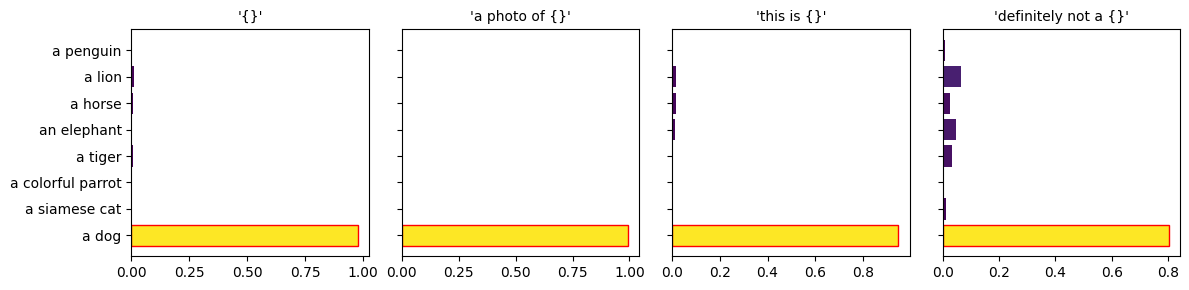

In [7]:
prompt_templates = ["{}","a photo of {}","this is {}", "definitely not a {}"]
dog_image_url = animal_images["dog"]
dog_image = load_image_from_url(dog_image_url)

plt.figure(figsize=(6,6))
plt.imshow(dog_image)
plt.axis("off")
plt.title("Input Image")
plt.show()

if dog_image:
    results = []
    print(f"\n🔍 Classifying the dog image with different prompt templates:")

    for template in prompt_templates:
        prompts = [template.format(category) for category in animal_categories]
        pred, conf, scores = classify_image(dog_image, prompts, show_plot=False)
        results.append(scores)
        print(f"  Template: '{template}' -> Prediction: {pred} (confidence: {conf:.3f})")

    # Plot
    fig, axes = plt.subplots(1, len(prompt_templates), figsize=(12, 3))
    if len(prompt_templates) == 1: axes = [axes]

    for i, (template, scores) in enumerate(zip(prompt_templates, results)):
        bars = axes[i].barh(animal_categories, scores, color=plt.cm.viridis(scores/scores.max()))
        bars[scores.argmax()].set_edgecolor('red')
        axes[i].set_title(f"'{template}'", fontsize=10)
        if i > 0: axes[i].set_yticklabels([])

    plt.tight_layout()
    plt.show()
else:
    print("Failed to load the dog image.")

Prompt selection affects zero-shot image classification, with "a photo of {}" being the most used one.


**Limitation of VLMs in Negation Reasoning:** This example demonstrates that This example shows that the dog image still receives the highest similarity score even with the negated prompt. The reason lies in semantic embedding proximity: in the shared embedding space, “definitely not a dog” ends up closer to “dog” than to “siamese cat” or “tiger.”

* The presence of the word dog in the prompt strongly anchors the representation.
* The overall semantic context remains centered on the concept of a dog, while the negation word contributes only weakly.

## Zero-Shot Cross-Modal Retrieval
Crossmodal retrieval is the task of finding relevant data across different modalities — for example, searching for an image using a text description, or retrieving a caption given an image.

This is especially important in today’s AI systems, where models need to understand and connect multiple forms of information (e.g., language, vision, and sometimes audio).

* Text → Image Retrieval (Text2Image)
  * Input: A text query (e.g., “red car on a snowy road”)
  * Output: The most relevant image(s) from a large image collection.
  * Use case: Image search engines, creative tools.

* Image → Text Retrieval (Image2Text)
  * Input: An image.
  * Output: The most relevant textual description (caption, tags, or documents).
  * Use case: Automatic captioning.

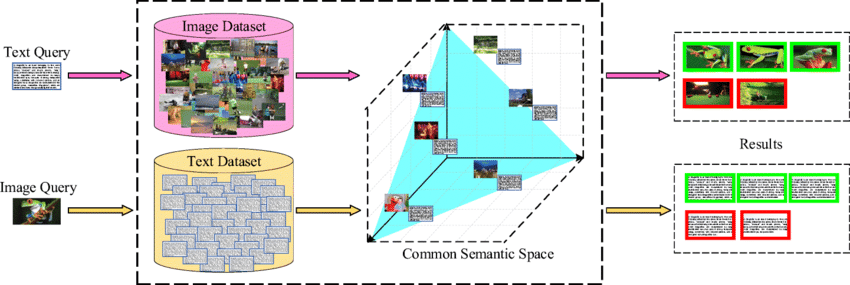

### Load dataset

*   Uses HuggingFace's Conceptual Caption dataset (validation split)
*   Loads 100 samples for demonstration
*   Each image is associated with a text description

In [8]:
dataset = load_dataset("conceptual_captions", split="validation")
dataset_subset = []

n_samples = 100
with tqdm(total=n_samples, desc="Loading images", unit="images") as pbar:
  for item in dataset:
    image = load_image_from_url(item['image_url'])
    if image is not None:
      dataset_subset.append({
          'image_url': item['image_url'],
          'caption': [item['caption']]
      })
      pbar.update(1)  # Update progress bar
      if len(dataset_subset) == n_samples:
        break

README.md: 0.00B [00:00, ?B/s]

unlabeled/train-00000-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/validation-00000-of-00001.parq(…):   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3318333 [00:00<?, ? examples/s]

...

Error loading image: cannot identify image file <_io.BytesIO object at 0x7ea68c1b2c00>


Loading images:  99%|█████████▉| 99/100 [01:01<00:00,  2.37images/s]

Error loading image: cannot identify image file <_io.BytesIO object at 0x7ea68c1b34c0>


Loading images: 100%|██████████| 100/100 [01:03<00:00,  1.58images/s]

Error loading image: cannot identify image file <_io.BytesIO object at 0x7ea68c1b2750>


In [9]:
dataset_subset[:3]

[{'image_url': 'https://i.pinimg.com/736x/66/01/6c/66016c3ba27c0e04f39e2bd81a934e3e--anita-ekberg-bob-hope.jpg',
  'caption': ['author : a life in photography -- in pictures']},
 {'image_url': 'http://i.dailymail.co.uk/i/pix/2014/11/05/1415187324676_wps_31_Home_is_a_little_Deer_Ivy.jpg',
  'caption': ['the - bedroom stone cottage can sleep people']},
 {'image_url': 'https://i.pinimg.com/736x/27/d5/94/27d59424cd786be35f0fa2a4ee11d088--minnie-mouse-nail-art-mickey-mouse-manicure.jpg',
  'caption': ["where 's the best place to show off your nails ? right in front of the castle , of course !"]}]

### Text-to-Image

In [10]:
def text_to_image_retrieval(text_idx: int, dataset_subset: List, top_k: int = 3):
    """Retrieve most similar images given a text query"""
    print(f"\n🔍 TEXT-TO-IMAGE RETRIEVAL")
    start_time = time.time()

    query_text = dataset_subset[text_idx]['caption']
    query_features = encode_text(query_text)
    print(f"Query: '{query_text}'")

    # Encode all images and compute similarities
    similarities = []
    valid_indices = []

    for idx, item in enumerate(dataset_subset):
        image = load_image_from_url(item['image_url'])
        if image is not None:
            image_features = encode_image(image)
            if image_features is not None:
                similarity = (query_features @ image_features.T).item()
                similarities.append(similarity)
                valid_indices.append(idx)

    # Get top-k results
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    total_time = time.time() - start_time
    print(f"  Total query time: {total_time:.3f}s")

    # Display results
    fig, axes = plt.subplots(1, top_k, figsize=(15, 3))
    if top_k == 1:
        axes = [axes]

    for i, idx in enumerate(top_indices):
        original_idx = valid_indices[idx]
        image_url = dataset_subset[original_idx]['image_url']
        image = load_image_from_url(image_url)
        similarity = similarities[idx]

        axes[i].imshow(image)
        axes[i].set_title(f"Rank {i+1}\nSim: {similarity:.3f}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Text-to-Image: '{query_text}'", fontsize=12)
    plt.tight_layout()
    plt.show()

    return [(valid_indices[idx], similarities[idx]) for idx in top_indices]


🔍 TEXT-TO-IMAGE RETRIEVAL
Query: '['the - bedroom stone cottage can sleep people']'
  Total query time: 18.771s


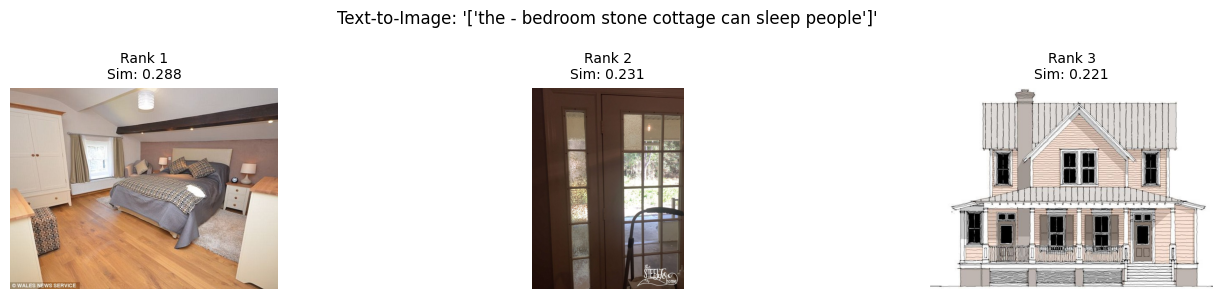

[(1, 0.28759765625), (27, 0.2313232421875), (78, 0.221435546875)]

In [11]:
text_to_image_retrieval(1, dataset_subset, 3)

#### Offline vs. Online Encoding

Encoding the entire database at query time is inefficient, since each search would require re-processing all items. A better approach is to pre-encode the database offline: embeddings are computed once and stored, so at query time only the query is encoded. Retrieval then reduces to a fast similarity search, greatly improving efficiency and scalability.

In [12]:
def precompute_image_db(dataset_subset: List[Dict]) -> Dict:
    embeddings_list = []
    valid_indices = []
    image_urls = []

    for idx, item in enumerate(tqdm(dataset_subset, desc="Encoding images")):
        image = load_image_from_url(item['image_url'])
        if image is not None:
            image_features = encode_image(image)
            if image_features is not None:
                embeddings_list.append(image_features.cpu().numpy().flatten())
                valid_indices.append(idx)
                image_urls.append(item['image_url'])

    embeddings_matrix = np.vstack(embeddings_list)
    embeddings_matrix = embeddings_matrix / np.linalg.norm(
        embeddings_matrix, axis=1, keepdims=True
    )

    embedding_db = {
        'embeddings': embeddings_matrix,
        'indices': valid_indices,
        'image_urls': image_urls
    }
    return embedding_db

def text_to_image_retrieval_efficient(
    text_idx: int,
    embedding_db: Dict,
    dataset_subset: List[Dict],
    top_k: int = 3
) -> List[Tuple[int, float]]:
    print(f"\n🔍 TEXT-TO-IMAGE RETRIEVAL")
    start_time = time.time()

    query_text = dataset_subset[text_idx]['caption']
    print(f"Query: '{query_text}'")

    query_features = encode_text(query_text)
    query_embedding = query_features.cpu().numpy().flatten()
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    similarities = embedding_db['embeddings'] @ query_embedding

    top_indices = np.argsort(similarities)[-top_k:][::-1]

    total_time = time.time() - start_time
    print(f"  Total query time: {total_time:.3f}s")

    fig, axes = plt.subplots(1, top_k, figsize=(15, 3))
    if top_k == 1:
        axes = [axes]

    for i, idx in enumerate(top_indices):
        original_idx = embedding_db['indices'][idx]
        image_url = embedding_db['image_urls'][idx]
        image = load_image_from_url(image_url)
        similarity = similarities[idx]

        axes[i].imshow(image)
        axes[i].set_title(f"Rank {i+1}\nSim: {similarity:.3f}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Text-to-Image: '{query_text}'", fontsize=12)
    plt.tight_layout()
    plt.show()

    return [(embedding_db['indices'][idx], similarities[idx]) for idx in top_indices]

In [13]:
image_embedding_db = precompute_image_db(dataset_subset)

Encoding images: 100%|██████████| 100/100 [00:18<00:00,  5.53it/s]



🔍 TEXT-TO-IMAGE RETRIEVAL
Query: '['the - bedroom stone cottage can sleep people']'
  Total query time: 0.015s


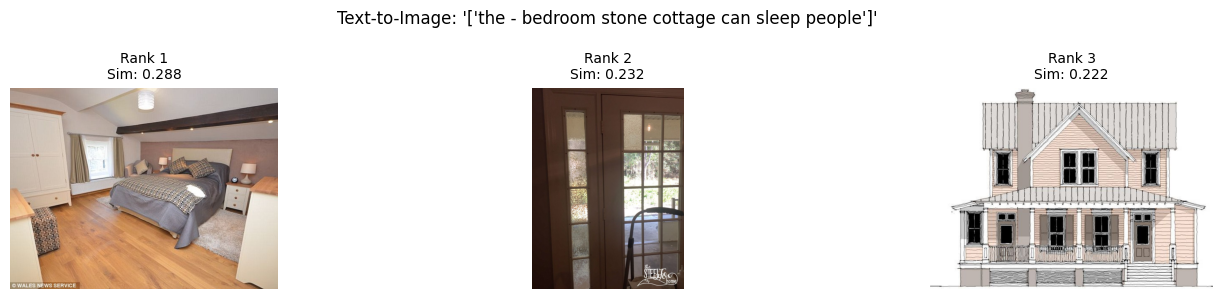

In [14]:
results = text_to_image_retrieval_efficient(
    text_idx=1,
    embedding_db=image_embedding_db,
    dataset_subset=dataset_subset,
    top_k=3
)

### Image-to-Text

In [15]:
def precompute_text_db(dataset_subset: List[Dict]) -> Dict:
    embeddings_list = []
    valid_indices = []
    captions = []

    for idx, item in enumerate(tqdm(dataset_subset, desc="Encoding captions")):
        text_features = encode_text(item['caption'])
        if text_features is not None:
            embeddings_list.append(text_features.cpu().numpy().flatten())
            valid_indices.append(idx)
            captions.append(item['caption'])

    embeddings_matrix = np.vstack(embeddings_list)
    embeddings_matrix = embeddings_matrix / np.linalg.norm(
        embeddings_matrix, axis=1, keepdims=True
    )

    embedding_db = {
        'embeddings': embeddings_matrix,
        'indices': valid_indices,
        'captions': captions
    }
    return embedding_db

def image_to_text_retrieval_efficient(
    image_idx: int,
    embedding_db: Dict,
    dataset_subset: List[Dict],
    top_k: int = 3
) -> List[Tuple[int, float]]:
    print(f"\n🔍 IMAGE-TO-TEXT RETRIEVAL")
    start_time = time.time()

    query_image_url = dataset_subset[image_idx]['image_url']
    query_image = load_image_from_url(query_image_url)

    query_features = encode_image(query_image)
    query_embedding = query_features.cpu().numpy().flatten()
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    similarities = embedding_db['embeddings'] @ query_embedding

    top_indices = np.argsort(similarities)[-top_k:][::-1]

    total_time = time.time() - start_time
    print(f"  Total query time: {total_time:.3f}s")

    fig = plt.figure(figsize=(15, 4))

    ax_img = plt.subplot(1, top_k + 1, 1)
    ax_img.imshow(query_image)
    ax_img.set_title("Query Image", fontsize=10)
    ax_img.axis('off')

    for i, idx in enumerate(top_indices):
        ax = plt.subplot(1, top_k + 1, i + 2)
        caption = embedding_db['captions'][idx]
        similarity = similarities[idx]

        ax.text(0.5, 0.5, f"Rank {i+1}\n\n{caption}\n\nSim: {similarity:.3f}",
                ha='center', va='center', wrap=True, fontsize=9)
        ax.axis('off')

    plt.suptitle("Image-to-Text Retrieval", fontsize=12)
    plt.tight_layout()
    plt.show()

    return [(embedding_db['indices'][idx], similarities[idx]) for idx in top_indices]

In [16]:
text_embedding_db = precompute_text_db(dataset_subset)

Encoding captions: 100%|██████████| 100/100 [00:01<00:00, 95.60it/s]



🔍 IMAGE-TO-TEXT RETRIEVAL
  Total query time: 0.041s


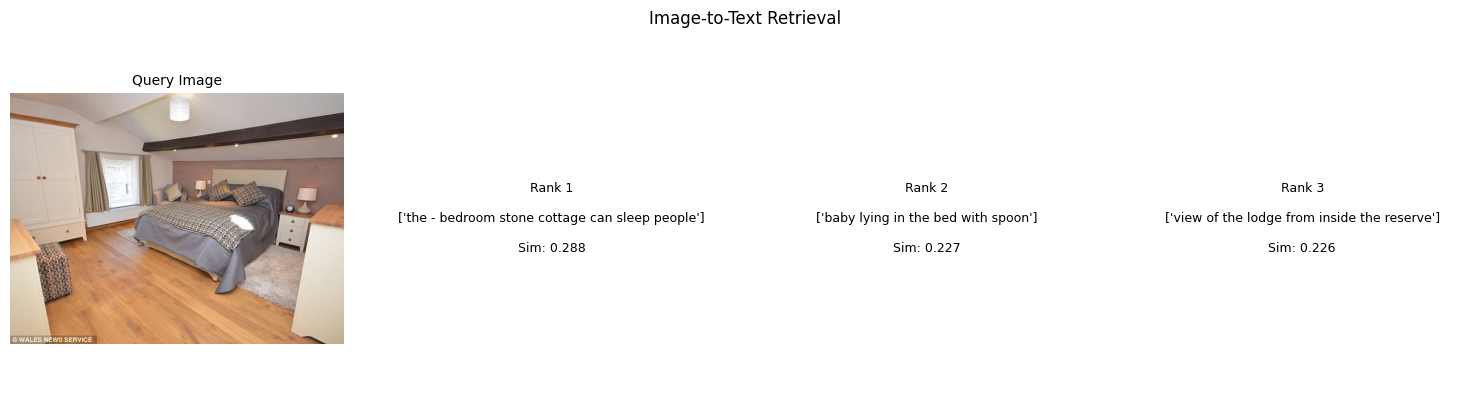

In [17]:
results = image_to_text_retrieval_efficient(
    image_idx=1,
    embedding_db=text_embedding_db,
    dataset_subset=dataset_subset,
    top_k=3
)